In [44]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
from pathlib import Path

In [45]:

def load_training_stats(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)

    # parse params + clusters (stored as strings like "{'n_clusters': 199}")
    df["params_dict"] = df["params"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else {})
    df["clusters_dict"] = df["clusters"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else {})

    # convenient columns (will be NaN if not present)
    df["n_clusters"] = df["params_dict"].apply(lambda d: d.get("n_clusters", np.nan) if isinstance(d, dict) else np.nan)
    df["eps"] = df["params_dict"].apply(lambda d: d.get("eps", np.nan) if isinstance(d, dict) else np.nan)
    df["min_samples"] = df["params_dict"].apply(lambda d: d.get("min_samples", np.nan) if isinstance(d, dict) else np.nan)

    return df

def load_test_metrics(path: str) -> pd.DataFrame:
    return pd.read_csv(path)

def best_f1_barplot(df: pd.DataFrame, outpath: str):
    best = (
        df.sort_values("f1_score", ascending=False)
          .groupby("method", as_index=False)
          .head(1)
          .sort_values("f1_score", ascending=False)
    )

    plt.figure()
    plt.bar(best["method"], best["f1_score"])
    plt.ylabel("F1-score (train)")
    plt.xlabel("Clustering method")
    plt.title("Best training F1-score per method")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.savefig(outpath, dpi=200)
    plt.show()
    plt.close()

def f1_vs_nclusters_lineplot(df: pd.DataFrame, method_name: str, outpath: str):
    sub = df[df["method"].str.lower() == method_name.lower()].dropna(subset=["n_clusters"]).sort_values("n_clusters")
    if sub.empty:
        print(f"[WARN] No rows found for method={method_name} with n_clusters.")
        return

    plt.figure()
    plt.plot(sub["n_clusters"], sub["f1_score"], marker="o")
    plt.xlabel("n_clusters")
    plt.ylabel("F1-score (train)")
    plt.title(f"{method_name}: F1-score vs number of clusters")
    plt.tight_layout()
    plt.savefig(outpath, dpi=200)
    plt.show()
    plt.close()

def cluster_size_hist_for_best_run(df: pd.DataFrame, outpath: str, bins: int = 30):
    best_run = df.sort_values("f1_score", ascending=False).iloc[0]
    sizes = [v for v in best_run["clusters_dict"].values() if isinstance(v, (int, float))]

    plt.figure()
    plt.hist(sizes, bins=bins)
    plt.xlabel("Cluster size (# sequences)")
    plt.ylabel("Count of clusters")
    plt.title(f"Cluster size distribution (best run: {best_run['method']}, params={best_run['params']})")
    plt.tight_layout()
    plt.savefig(outpath, dpi=200)
    plt.show()
    plt.close()




In [46]:
score = 321
training_csv = f"/home/dsi/chenbis/repos/sol_lab/clustering models prediction/output_by_scores/{score}/training_stats.csv"
test_csv = f"/home/dsi/chenbis/repos/sol_lab/clustering models prediction/output_by_scores/{score}/test_metrics.csv"
outdir = Path(f"/home/dsi/chenbis/repos/sol_lab/clustering models prediction/figures/{score}")
outdir.mkdir(parents=True, exist_ok=True)
train_df = load_training_stats(training_csv)
test_df = load_test_metrics(test_csv)

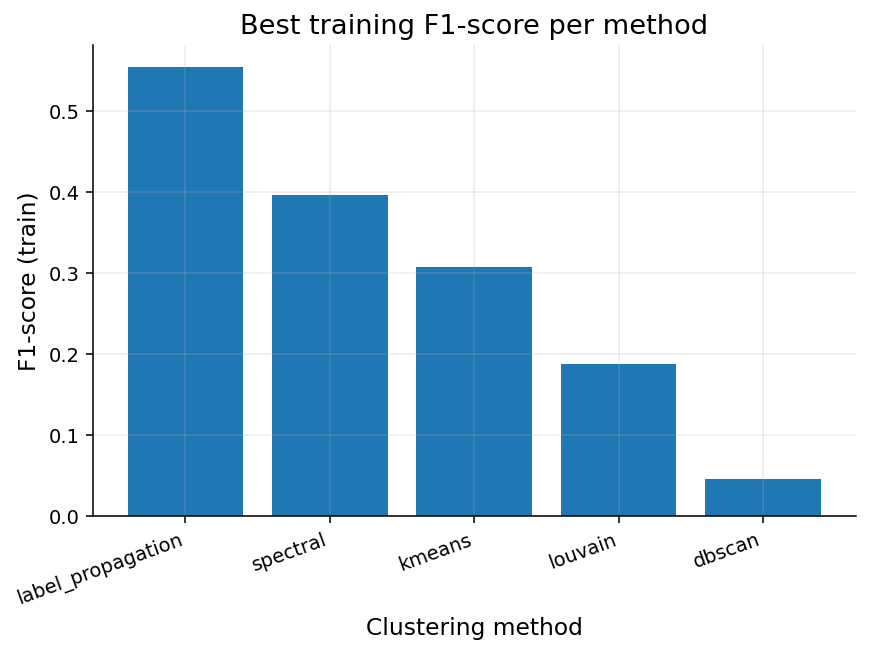

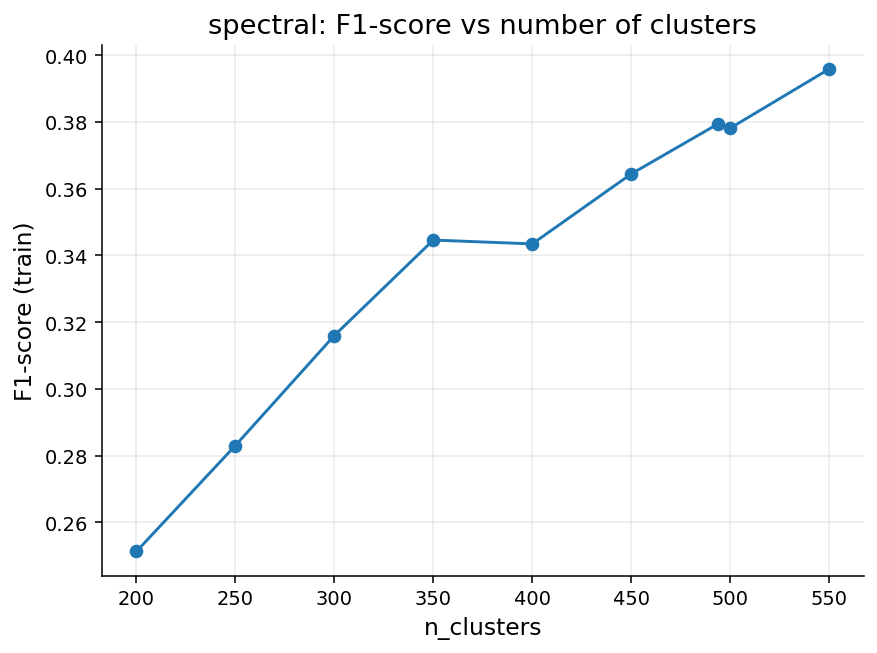

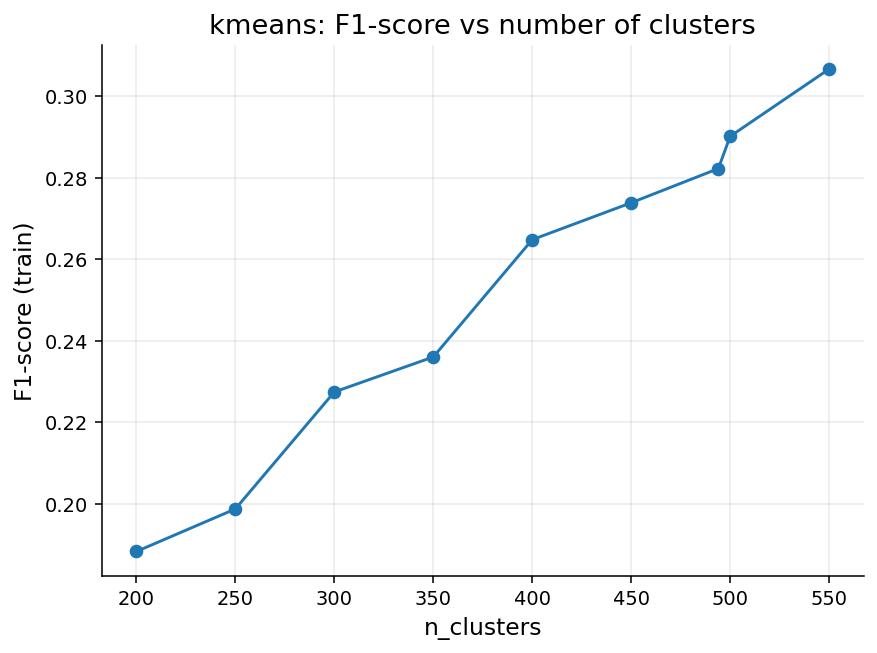

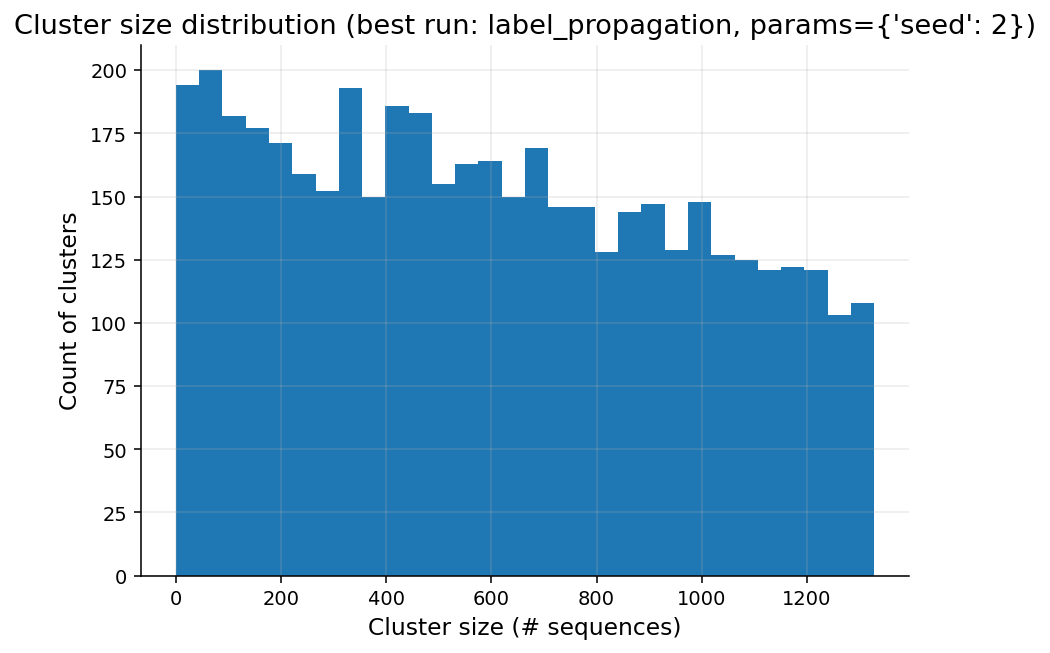

Best training run:
method      label_propagation
params            {'seed': 2}
accuracy             0.582327
recall               0.582327
f1_score             0.553748
Name: 22, dtype: object

Test metrics:
   test_accuracy  test_recall  test_f1_score
0       0.289076     0.289076       0.182083


In [47]:


# 1) best per method
best_f1_barplot(train_df, str(outdir / "train_best_f1_per_method.png"))

# 2) parameter sensitivity (pick what you actually use; you can call both)
f1_vs_nclusters_lineplot(train_df, "spectral", str(outdir / "spectral_f1_vs_nclusters.png"))
f1_vs_nclusters_lineplot(train_df, "kmeans", str(outdir / "kmeans_f1_vs_nclusters.png"))

# 3) cluster size distribution for best run overall
cluster_size_hist_for_best_run(train_df, str(outdir / "cluster_size_hist_best_run.png"))

# 4) quick print best model + test metrics (optional)
best_run = train_df.sort_values("f1_score", ascending=False).iloc[0]
print("Best training run:")
print(best_run[["method", "params", "accuracy", "recall", "f1_score"]])
print("\nTest metrics:")
print(test_df)

In [48]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
from pathlib import Path

# ---------- Global "pretty" Matplotlib defaults (no explicit colors) ----------
plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "-",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
})

def load_training_stats(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    df["params_dict"] = df["params"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else {})
    df["clusters_dict"] = df["clusters"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else {})

    df["n_clusters"] = df["params_dict"].apply(lambda d: d.get("n_clusters", np.nan) if isinstance(d, dict) else np.nan)
    df["eps"] = df["params_dict"].apply(lambda d: d.get("eps", np.nan) if isinstance(d, dict) else np.nan)
    df["min_samples"] = df["params_dict"].apply(lambda d: d.get("min_samples", np.nan) if isinstance(d, dict) else np.nan)
    return df

def best_run(df: pd.DataFrame) -> pd.Series:
    return df.sort_values("f1_score", ascending=False).iloc[0]

def best_per_method(df: pd.DataFrame) -> pd.DataFrame:
    out = (df.sort_values("f1_score", ascending=False)
             .groupby("method", as_index=False)
             .head(1)
             .sort_values("f1_score", ascending=False)
             .reset_index(drop=True))
    return out

def plot_train_best_per_method_grouped(df: pd.DataFrame, outpath: str, title_suffix: str = ""):
    best = best_per_method(df)
    metrics = ["accuracy", "recall", "f1_score"]
    labels = ["Accuracy", "Recall", "F1-score"]

    x = np.arange(len(best))
    width = 0.25

    fig, ax = plt.subplots(figsize=(8.2, 4.8), constrained_layout=True)
    for i, m in enumerate(metrics):
        ax.bar(x + (i-1)*width, best[m].values, width, label=labels[i])

    ax.set_xticks(x)
    ax.set_xticklabels(best["method"].tolist(), rotation=15, ha="right")
    ax.set_ylabel("Score")
    ax.set_title(f"Best training performance per method{title_suffix}")
    ax.set_ylim(0, float(best[metrics].max().max()) * 1.15)
    ax.legend(ncol=3, loc="upper center")
    fig.savefig(outpath)
    plt.close(fig)

def plot_f1_boxplot(df: pd.DataFrame, outpath: str, title_suffix: str = ""):
    methods = sorted(df["method"].unique().tolist())
    data = [df.loc[df["method"] == m, "f1_score"].values for m in methods]

    fig, ax = plt.subplots(figsize=(8.2, 4.8), constrained_layout=True)
    ax.boxplot(data, labels=methods, showmeans=True)
    ax.set_ylabel("F1-score (train)")
    ax.set_title(f"Training F1-score distribution by method{title_suffix}")
    ax.set_ylim(0, float(df["f1_score"].max()) * 1.15)
    plt.setp(ax.get_xticklabels(), rotation=15, ha="right")
    fig.savefig(outpath)
    plt.close(fig)

def plot_f1_vs_nclusters(df: pd.DataFrame, method: str, outpath: str, title_suffix: str = ""):
    sub = df[df["method"].str.lower() == method.lower()].dropna(subset=["n_clusters"]).sort_values("n_clusters")
    if sub.empty:
        return

    fig, ax = plt.subplots(figsize=(8.2, 4.8), constrained_layout=True)
    ax.plot(sub["n_clusters"], sub["f1_score"], marker="o")

    best_idx = sub["f1_score"].idxmax()
    bx = sub.loc[best_idx, "n_clusters"]
    by = sub.loc[best_idx, "f1_score"]
    ax.scatter([bx], [by], marker="D", s=60, label=f"Best: n_clusters={int(bx)}, F1={by:.3f}")

    ax.set_xlabel("Number of clusters (n_clusters)")
    ax.set_ylabel("F1-score (train)")
    ax.set_title(f"{method.title()} performance vs n_clusters{title_suffix}")
    ax.set_ylim(0, float(sub["f1_score"].max()) * 1.2)
    ax.legend(loc="best")
    fig.savefig(outpath)
    plt.close(fig)

def plot_cluster_size_hist(df: pd.DataFrame, outpath: str, logx: bool = False, title_suffix: str = ""):
    br = best_run(df)
    sizes = [v for v in br["clusters_dict"].values() if isinstance(v, (int, float)) and v > 0]

    fig, ax = plt.subplots(figsize=(8.2, 4.8), constrained_layout=True)
    ax.hist(sizes, bins=35)

    if logx:
        ax.set_xscale("log")
        ax.set_xlabel("Cluster size (# sequences, log scale)")
        ax.set_title(f"Cluster size distribution (log-x){title_suffix}")
    else:
        ax.set_xlabel("Cluster size (# sequences)")
        ax.set_title(f"Cluster size distribution{title_suffix}")

    ax.set_ylabel("Number of clusters")
    fig.savefig(outpath)
    plt.close(fig)

def plot_dataset_comparison(summary_df: pd.DataFrame, outpath: str):
    """
    summary_df columns expected:
    dataset, train_f1, test_f1, test_recall, test_accuracy, method, params
    """
    # Order datasets as provided
    datasets = summary_df["dataset"].tolist()
    x = np.arange(len(datasets))
    w = 0.25

    fig, ax = plt.subplots(figsize=(9.0, 5.0), constrained_layout=True)
    ax.bar(x - w, summary_df["test_accuracy"], w, label="Test Accuracy")
    ax.bar(x,      summary_df["test_recall"],   w, label="Test Recall")
    ax.bar(x + w,  summary_df["test_f1"],       w, label="Test F1-score")

    ax.set_xticks(x)
    ax.set_xticklabels(datasets, rotation=10, ha="right")
    ax.set_ylabel("Score")
    ax.set_title("Test performance across dataset confidence settings")
    ax.set_ylim(0, float(summary_df[["test_accuracy","test_recall","test_f1"]].max().max()) * 1.2)
    ax.legend(ncol=3, loc="upper center")
    fig.savefig(outpath)
    plt.close(fig)

def plot_train_test_gap(summary_df: pd.DataFrame, outpath: str):
    gap = summary_df["train_f1"] - summary_df["test_f1"]
    x = np.arange(len(summary_df))

    fig, ax = plt.subplots(figsize=(9.0, 4.8), constrained_layout=True)
    ax.bar(x, gap)
    ax.set_xticks(x)
    ax.set_xticklabels(summary_df["dataset"].tolist(), rotation=10, ha="right")
    ax.set_ylabel("Train F1 - Test F1")
    ax.set_title("Generalization gap across datasets")
    fig.savefig(outpath)
    plt.close(fig)

def run_for_multiple_datasets(dataset_map: dict, outdir: str = "figures_pretty_all"):
    """
    dataset_map example:
    {
      "score=3":   {"train": "score3_training_stats.csv", "test": "score3_test_metrics.csv"},
      "score≥2":   {"train": "score23_training_stats.csv", "test": "score23_test_metrics.csv"},
      "score≥1":   {"train": "score123_training_stats.csv","test": "score123_test_metrics.csv"},
    }
    """
    outdir = Path(outdir)
    outdir.mkdir(parents=True, exist_ok=True)

    rows = []
    for ds_name, paths in dataset_map.items():
        tr = load_training_stats(paths["train"])
        te = pd.read_csv(paths["test"])

        br = best_run(tr)

        # Save per-dataset “nice” figures
        suffix = f" ({ds_name})"
        plot_train_best_per_method_grouped(tr, str(outdir / f"{ds_name}_best_per_method.png"), title_suffix=suffix)
        plot_f1_boxplot(tr, str(outdir / f"{ds_name}_f1_boxplot.png"), title_suffix=suffix)
        plot_f1_vs_nclusters(tr, "spectral", str(outdir / f"{ds_name}_spectral_curve.png"), title_suffix=suffix)
        plot_f1_vs_nclusters(tr, "kmeans", str(outdir / f"{ds_name}_kmeans_curve.png"), title_suffix=suffix)
        plot_cluster_size_hist(tr, str(outdir / f"{ds_name}_cluster_hist.png"), logx=False, title_suffix=suffix)
        plot_cluster_size_hist(tr, str(outdir / f"{ds_name}_cluster_hist_logx.png"), logx=True, title_suffix=suffix)

        rows.append({
            "dataset": ds_name,
            "method": br["method"],
            "params": br["params"],
            "train_f1": float(br["f1_score"]),
            "test_accuracy": float(te["test_accuracy"].iloc[0]),
            "test_recall": float(te["test_recall"].iloc[0]),
            "test_f1": float(te["test_f1_score"].iloc[0]),
        })

    summary = pd.DataFrame(rows)

    # Cross-dataset comparison figures
    plot_dataset_comparison(summary, str(outdir / "ALL_test_performance_comparison.png"))
    plot_train_test_gap(summary, str(outdir / "ALL_train_test_gap.png"))

    # Save summary table for Results
    summary.to_csv(outdir / "ALL_summary_table.csv", index=False)
    return summary

dataset_map = {
  "score=3": {"train":"output_by_scores/3/training_stats.csv", "test":"output_by_scores/3/test_metrics.csv"},
  "score≥2": {"train":"output_by_scores/32/training_stats.csv","test":"output_by_scores/32/test_metrics.csv"},
  "score≥1": {"train":"output_by_scores/321/training_stats.csv","test":"output_by_scores/321/test_metrics.csv"},
}
summary = run_for_multiple_datasets(dataset_map, outdir="figures_pretty_all")


/tmp/ipykernel_2576366/3223302043.py:71: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=methods, showmeans=True)
/tmp/ipykernel_2576366/3223302043.py:71: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=methods, showmeans=True)
/tmp/ipykernel_2576366/3223302043.py:71: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=methods, showmeans=True)


In [49]:
plot_dataset_comparison(summary, str(Path("figures_pretty_all") / "test_metrics_comparison.png"))

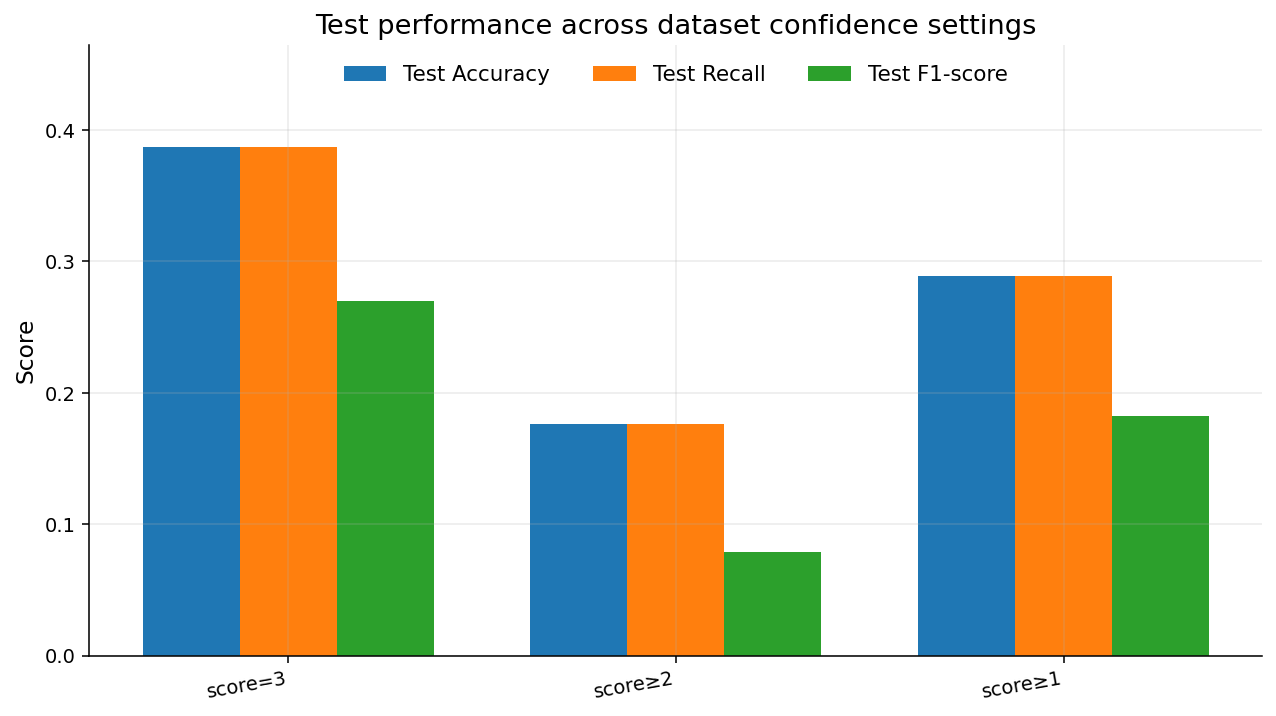

In [50]:

datasets = summary["dataset"].tolist()
x = np.arange(len(datasets))
w = 0.25

fig, ax = plt.subplots(figsize=(9.0, 5.0), constrained_layout=True)
ax.bar(x - w, summary["test_accuracy"], w, label="Test Accuracy")
ax.bar(x,      summary["test_recall"],   w, label="Test Recall")
ax.bar(x + w,  summary["test_f1"],       w, label="Test F1-score")

ax.set_xticks(x)
ax.set_xticklabels(datasets, rotation=10, ha="right")
ax.set_ylabel("Score")
ax.set_title("Test performance across dataset confidence settings")
ax.set_ylim(0, float(summary[["test_accuracy","test_recall","test_f1"]].max().max()) * 1.2)
ax.legend(ncol=3, loc="upper center")
plt.show()

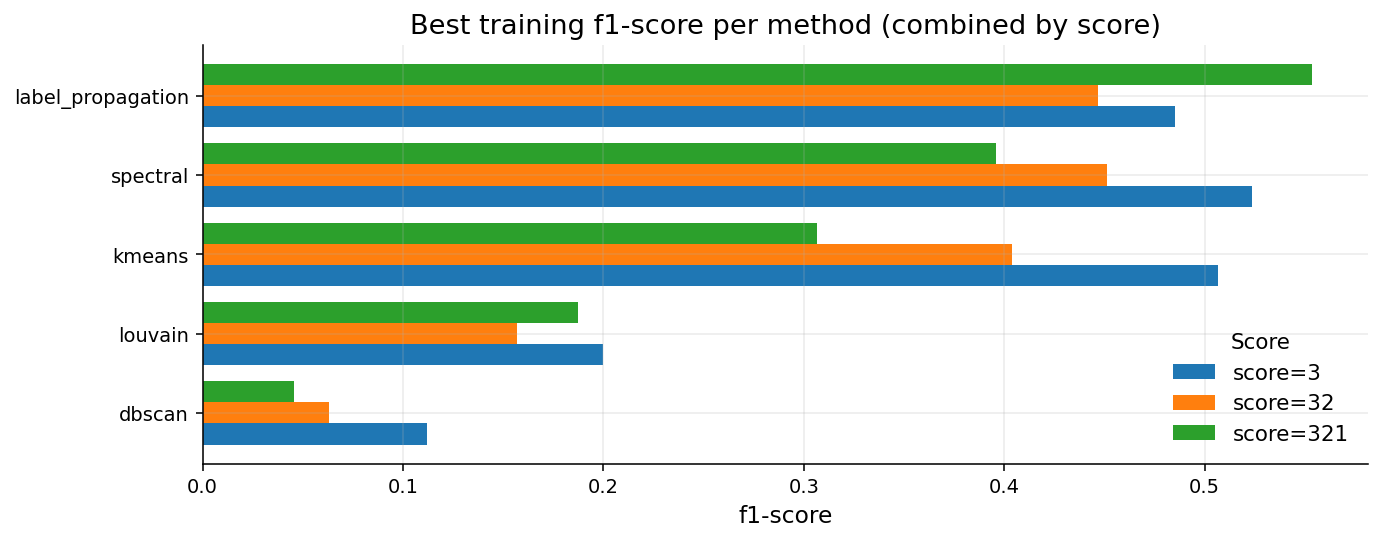

In [51]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

scores = [3, 32, 321]
metric = "f1_score"

all_best = []

for score in scores:
    training_csv = f"/home/dsi/chenbis/repos/sol_lab/clustering models prediction/output_by_scores/{score}/training_stats.csv"
    test_csv = f"/home/dsi/chenbis/repos/sol_lab/clustering models prediction/output_by_scores/{score}/test_metrics.csv"

    outdir = Path(f"/home/dsi/chenbis/repos/sol_lab/clustering models prediction/figures/{score}")
    outdir.mkdir(parents=True, exist_ok=True)

    train_df = load_training_stats(training_csv)
    test_df = load_test_metrics(test_csv)  # not used in this plot, but kept if you need it later

    required = {"method", metric}
    missing = required - set(train_df.columns)
    if missing:
        raise ValueError(f"train_df missing columns for score={score}: {sorted(missing)}")

    best = (
        train_df.dropna(subset=[metric])
        .sort_values(metric, ascending=False)
        .groupby("method", as_index=False)
        .head(1)
        .loc[:, ["method", metric]]
        .assign(score=score)
    )

    all_best.append(best)

all_best = pd.concat(all_best, ignore_index=True)

# ---- Build a method x score matrix for plotting ----
score_vals = sorted(all_best["score"].unique())
mat = all_best.pivot(index="method", columns="score", values=metric)

# Optional: choose a stable, meaningful method order (by average across scores)
method_order = mat.mean(axis=1, skipna=True).sort_values(ascending=True).index
mat = mat.reindex(method_order)

# ---- Plot grouped horizontal bars ----
methods = mat.index.tolist()
y = np.arange(len(methods))
bar_h = 0.8 / len(score_vals)  # total thickness ~0.8 split across scores

plt.figure(figsize=(10, 0.4 * len(methods) + 2))

for i, s in enumerate(score_vals):
    # center the grouped bars around each y
    offset = (i - (len(score_vals) - 1) / 2) * bar_h
    plt.barh(y + offset, mat[s].values, height=bar_h, label=f"score={s}")

plt.yticks(y, methods)
plt.xlabel(metric.replace("_", "-"))
plt.title(f"Best training {metric.replace('_','-')} per method (combined by score)")
plt.legend(title="Score")
plt.tight_layout()

# Save one combined figure (pick whatever directory you want)
combined_outdir = Path("/home/dsi/chenbis/repos/sol_lab/clustering models prediction/figures/combined")
combined_outdir.mkdir(parents=True, exist_ok=True)
plt.savefig(combined_outdir / f"best_{metric}_per_method_by_score.png", dpi=200)

# If you're running interactively:
# plt.show()


/tmp/ipykernel_2576366/2854762107.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis")


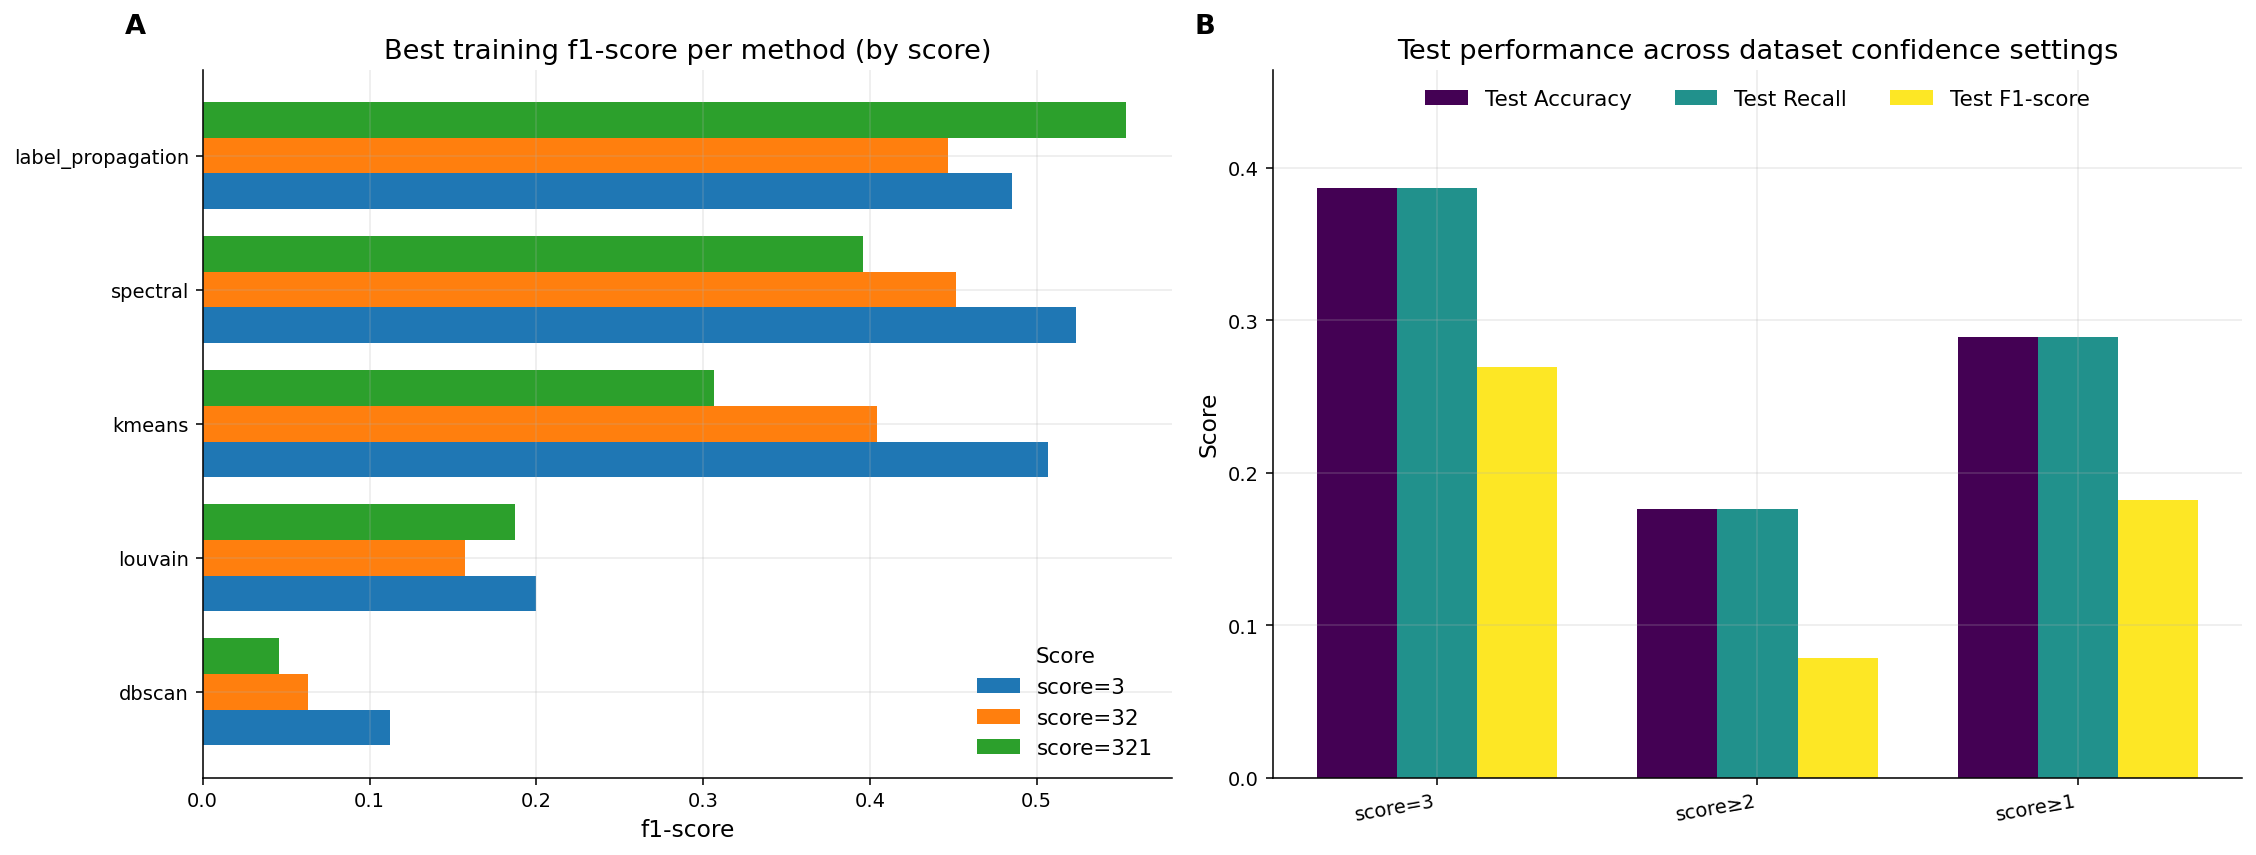

In [52]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

scores = [3, 32, 321]
metric = "f1_score"

import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Number of distinct bars needed
n_scores = len(score_vals)          # Panel A
n_metrics = 3                       # Panel B

# Use the same colormap
cmap = cm.get_cmap("viridis")

score_colors = [cmap(i / (n_scores - 1)) for i in range(n_scores)]
metric_colors = [cmap(i / (n_metrics - 1)) for i in range(n_metrics)]


# ---------- Build combined "best per method" across scores ----------
all_best = []

for score in scores:
    training_csv = f"/home/dsi/chenbis/repos/sol_lab/clustering models prediction/output_by_scores/{score}/training_stats.csv"
    train_df = load_training_stats(training_csv)

    required = {"method", metric}
    missing = required - set(train_df.columns)
    if missing:
        raise ValueError(f"train_df missing columns for score={score}: {sorted(missing)}")

    best = (
        train_df.dropna(subset=[metric])
        .sort_values(metric, ascending=False)
        .groupby("method", as_index=False)
        .head(1)
        .loc[:, ["method", metric]]
        .assign(score=score)
    )
    all_best.append(best)

all_best = pd.concat(all_best, ignore_index=True)

# method x score matrix
score_vals = sorted(all_best["score"].unique())
mat = all_best.pivot(index="method", columns="score", values=metric)

# Order methods by average performance (optional, but makes the plot easier to read)
method_order = mat.mean(axis=1, skipna=True).sort_values(ascending=True).index
mat = mat.reindex(method_order)

# ---------- Your "summary" grouped bar plot data ----------
datasets = summary["dataset"].tolist()
x = np.arange(len(datasets))
w = 0.25

# ---------- Create 1x2 panel figure ----------
fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

# ===== Panel A: combined best training F1 per method across scores =====
ax = axes[0]

methods = mat.index.tolist()
y = np.arange(len(methods))
bar_h = 0.8 / len(score_vals)

for i, s in enumerate(score_vals):
    offset = (i - (len(score_vals) - 1) / 2) * bar_h
    ax.barh(y + offset, mat[s].values, height=bar_h, label=f"score={s}")

ax.set_yticks(y)
ax.set_yticklabels(methods)
ax.set_xlabel(metric.replace("_", "-"))
ax.set_title(f"Best training {metric.replace('_','-')} per method (by score)")
ax.legend(title="Score", loc="lower right")

# ===== Panel B: test performance across dataset confidence settings =====
ax = axes[1]

ax.bar(x - w, summary["test_accuracy"], w, label="Test Accuracy", color=metric_colors[0])
ax.bar(x,      summary["test_recall"],   w, label="Test Recall", color=metric_colors[1])
ax.bar(x + w,  summary["test_f1"],       w, label="Test F1-score", color=metric_colors[2])

ax.set_xticks(x)
ax.set_xticklabels(datasets, rotation=10, ha="right")
ax.set_ylabel("Score")
ax.set_title("Test performance across dataset confidence settings")
ax.set_ylim(0, float(summary[["test_accuracy","test_recall","test_f1"]].max().max()) * 1.2)
ax.legend(ncol=3, loc="upper center")

# ---------- Add panel labels like your example ----------
panel_labels = ["A", "B"]
for ax, label in zip(axes.flat, panel_labels):
    ax.text(
        -0.08, 1.08, label,
        transform=ax.transAxes,
        fontsize=14,
        fontweight="bold",
        va="top",
        ha="left"
    )

plt.show()

# Optional: save
# outpath = Path("/home/dsi/chenbis/repos/sol_lab/clustering models prediction/figures/combined") / "panel_train_test_comparison.png"
# outpath.parent.mkdir(parents=True, exist_ok=True)
# fig.savefig(outpath, dpi=200)


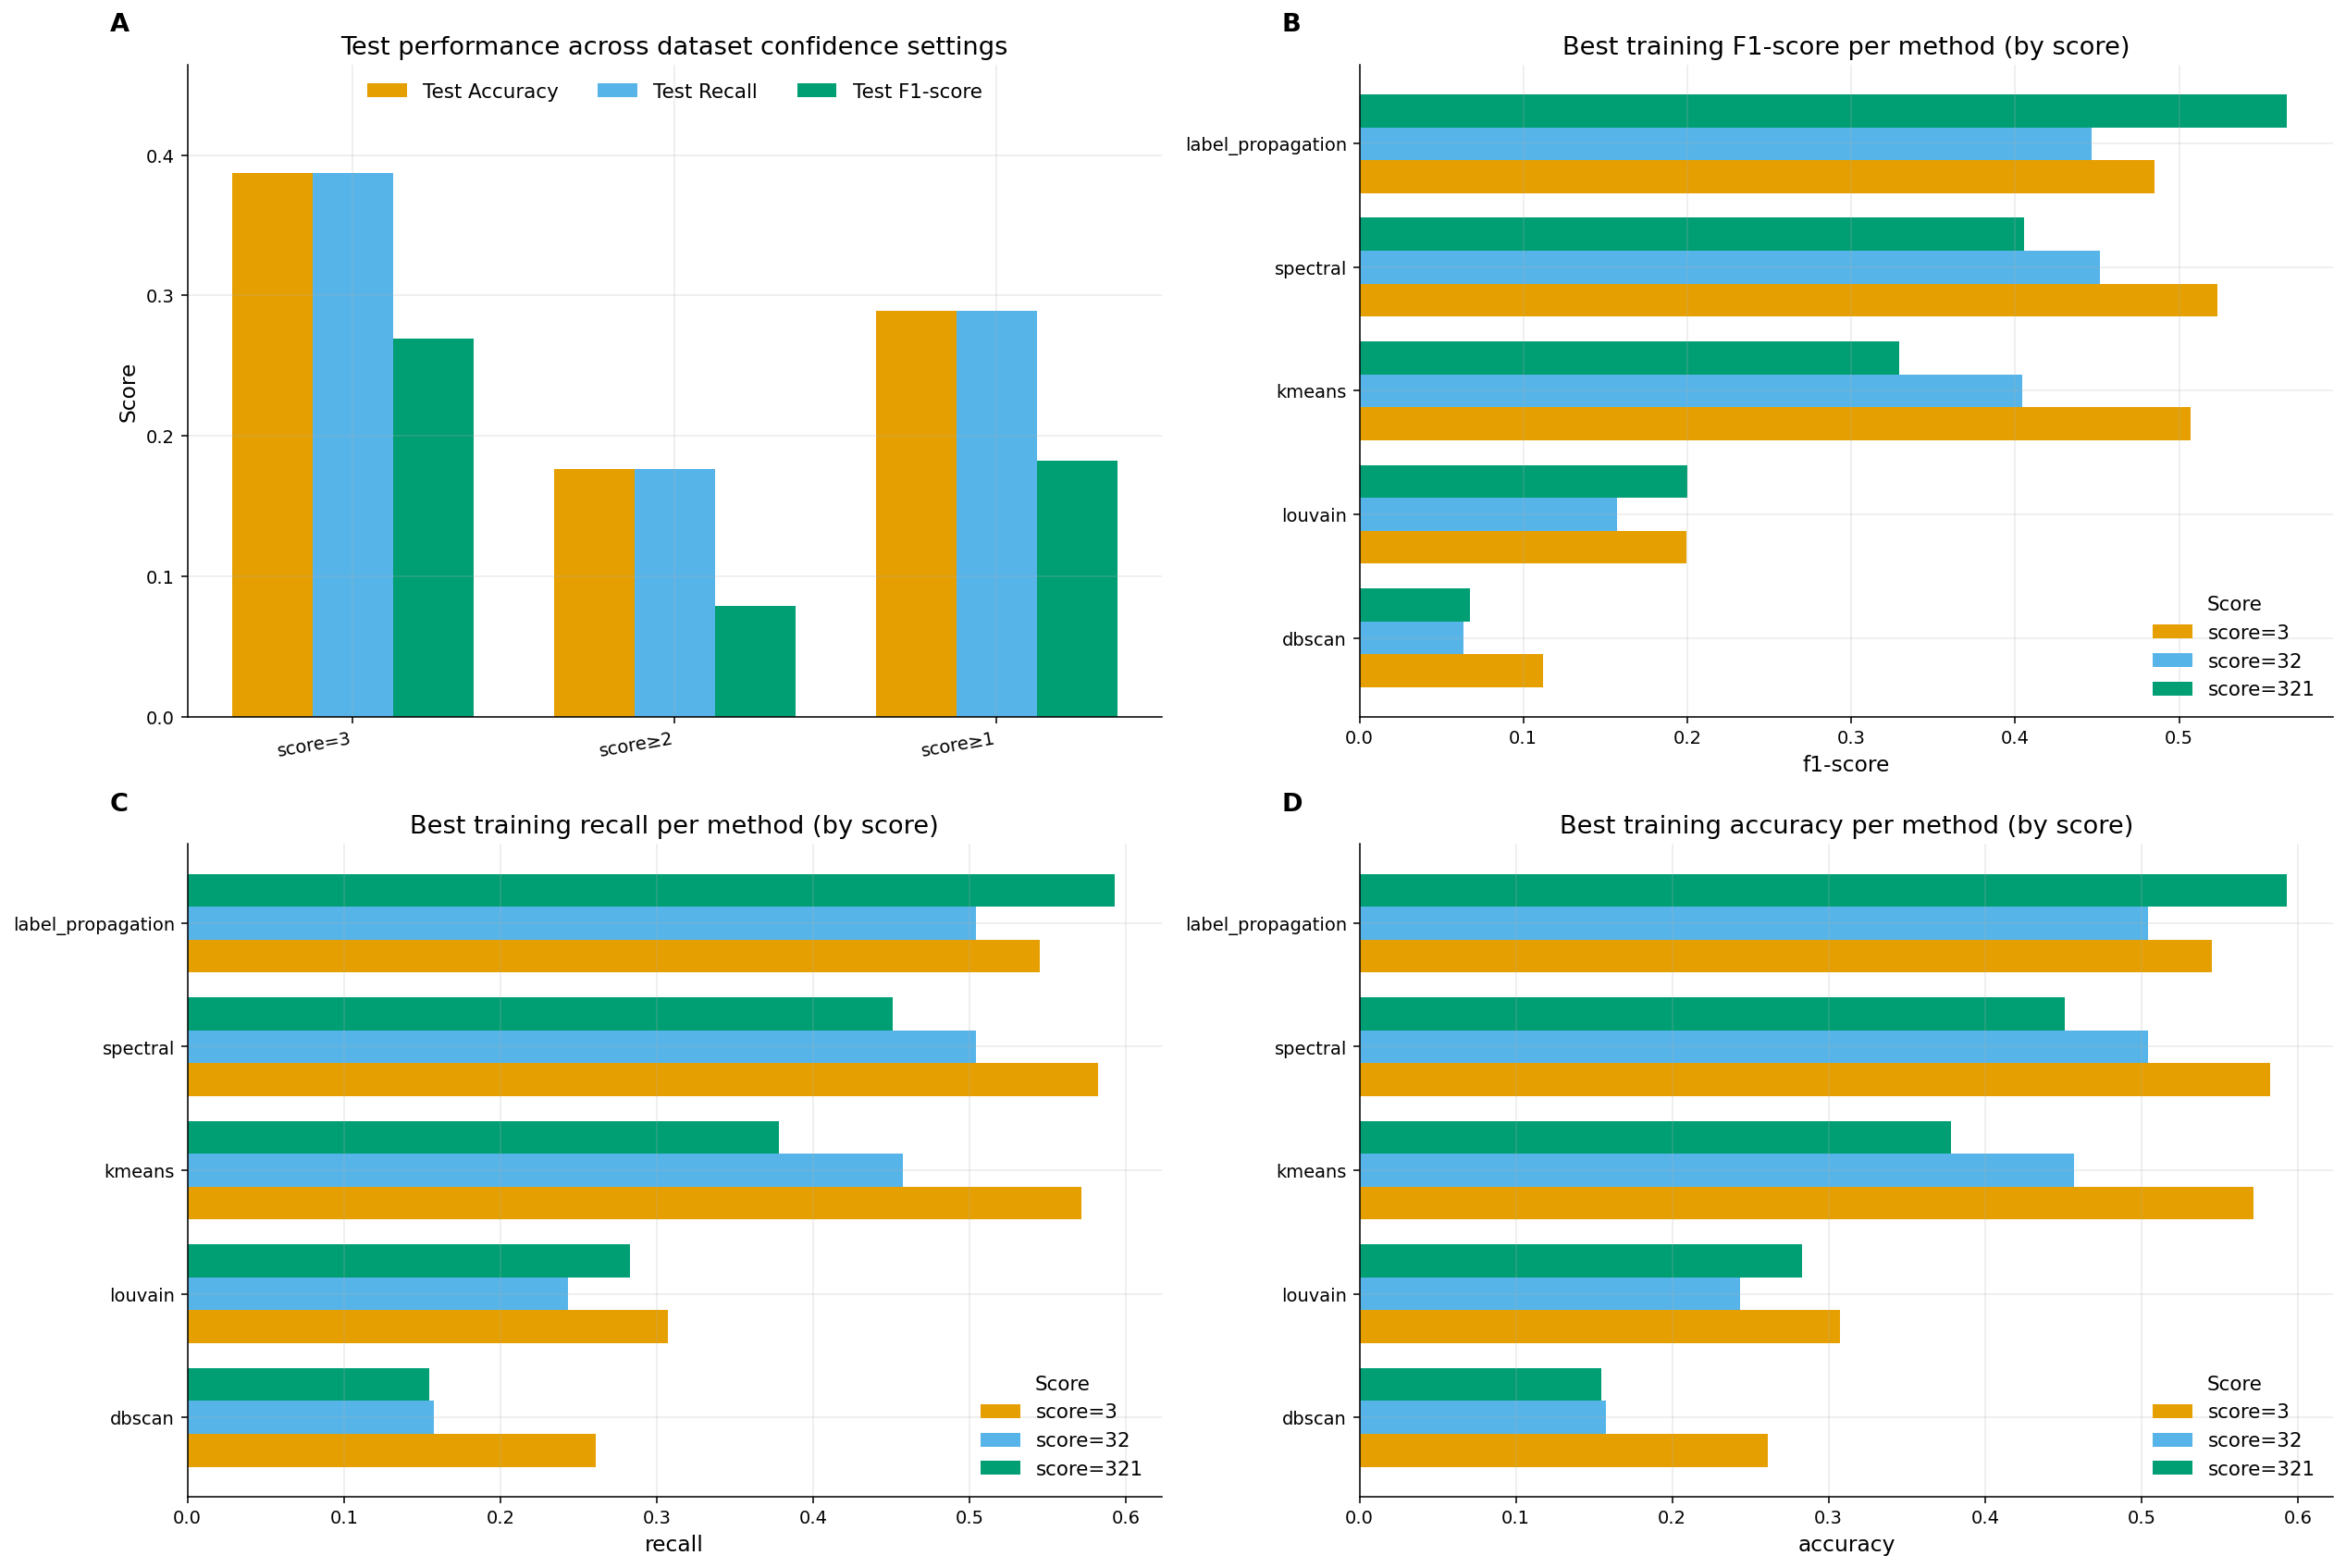

In [57]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

scores = [3, 32, 321]
train_metrics = ["f1_score", "recall", "accuracy"]

# ---------- Collect best-per-method train metrics ----------
all_best = []

for score in scores:
    training_csv = f"/home/dsi/chenbis/repos/sol_lab/clustering models prediction/output_by_scores/{score}/training_stats.csv"
    train_df = load_training_stats(training_csv)

    required = {"method"} | set(train_metrics)
    missing = required - set(train_df.columns)
    if missing:
        raise ValueError(f"train_df missing columns for score={score}: {sorted(missing)}")

    for metric in train_metrics:
        best = (
            train_df.dropna(subset=[metric])
            .sort_values(metric, ascending=False)
            .groupby("method", as_index=False)
            .head(1)
            .loc[:, ["method", metric]]
            .assign(score=score, metric=metric)
            .rename(columns={metric: "value"})
        )
        all_best.append(best)

all_best = pd.concat(all_best, ignore_index=True)

# ---------- Color palette (shared) ----------
okabe_ito = [
    "#E69F00",  # orange
    "#56B4E9",  # sky blue
    "#009E73",  # bluish green
    "#F0E442",  # yellow
    "#0072B2",  # blue
    "#D55E00",  # vermillion
    "#CC79A7",  # reddish purple
]

score_colors = okabe_ito[:len(score_vals)]
metric_colors = score_colors


# ---------- Helper function for train metric panels ----------
def plot_train_metric(ax, metric_name, title):
    mat = (
        all_best[all_best["metric"] == metric_name]
        .pivot(index="method", columns="score", values="value")
    )

    # Order methods by average performance
    order = mat.mean(axis=1).sort_values(ascending=True).index
    mat = mat.reindex(order)

    methods = mat.index.tolist()
    y = np.arange(len(methods))
    bar_h = 0.8 / len(score_vals)

    for i, (s, color) in enumerate(zip(score_vals, score_colors)):
        offset = (i - (len(score_vals) - 1) / 2) * bar_h
        ax.barh(y + offset, mat[s].values, height=bar_h, color=color, label=f"score={s}")

    ax.set_yticks(y)
    ax.set_yticklabels(methods)
    ax.set_xlabel(metric_name.replace("_", "-"))
    ax.set_title(title)

# ---------- Build figure ----------
fig, axes = plt.subplots(2, 2, figsize=(18, 12), constrained_layout=True)

# ===== Panel A: Test metrics =====
datasets = summary["dataset"].tolist()
x = np.arange(len(datasets))
w = 0.25

axes[0, 0].bar(x - w, summary["test_accuracy"], w, label="Test Accuracy", color=metric_colors[0])
axes[0, 0].bar(x,      summary["test_recall"],   w, label="Test Recall",   color=metric_colors[1])
axes[0, 0].bar(x + w,  summary["test_f1"],       w, label="Test F1-score", color=metric_colors[2])

axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(datasets, rotation=10, ha="right")
axes[0, 0].set_ylabel("Score")
axes[0, 0].set_title("Test performance across dataset confidence settings")
axes[0, 0].set_ylim(
    0,
    float(summary[["test_accuracy","test_recall","test_f1"]].max().max()) * 1.2
)
axes[0, 0].legend(ncol=3, loc="upper center", frameon=False)

# ===== Panel B: Train F1 =====
plot_train_metric(
    axes[0, 1],
    "f1_score",
    "Best training F1-score per method (by score)"
)
axes[0, 1].legend(title="Score", frameon=False)



# ===== Panel C: Train Recall =====
plot_train_metric(
    axes[1, 0],
    "recall",
    "Best training recall per method (by score)"
)
axes[1, 0].legend(title="Score", frameon=False)

# ===== Panel D: Train Accuracy =====
plot_train_metric(
    axes[1, 1],
    "accuracy",
    "Best training accuracy per method (by score)"
)
axes[1, 1].legend(title="Score", frameon=False)

# ---------- Panel labels ----------
panel_labels = ["A", "B", "C", "D"]
for ax, label in zip(axes.flat, panel_labels):
    ax.text(
        -0.08, 1.08, label,
        transform=ax.transAxes,
        fontsize=14,
        fontweight="bold",
        va="top",
        ha="left"
    )

plt.show()

# Optional save
# outpath = Path("/home/dsi/chenbis/repos/sol_lab/clustering models prediction/figures/combined/train_test_4panel.png")
# outpath.parent.mkdir(parents=True, exist_ok=True)
# fig.savefig(outpath, dpi=200)


In [54]:
okabe_ito

['#E69F00', '#56B4E9', '#009E73', '#F0E442', '#0072B2', '#D55E00', '#CC79A7']

In [55]:
score_colors = okabe_ito[:len(score_vals)]
metric_colors = okabe_ito[len(score_vals):len(score_vals)+3]
print("Score colors:", score_colors, "Metric colors:", metric_colors)

Score colors: ['#E69F00', '#56B4E9', '#009E73'] Metric colors: ['#F0E442', '#0072B2', '#D55E00']


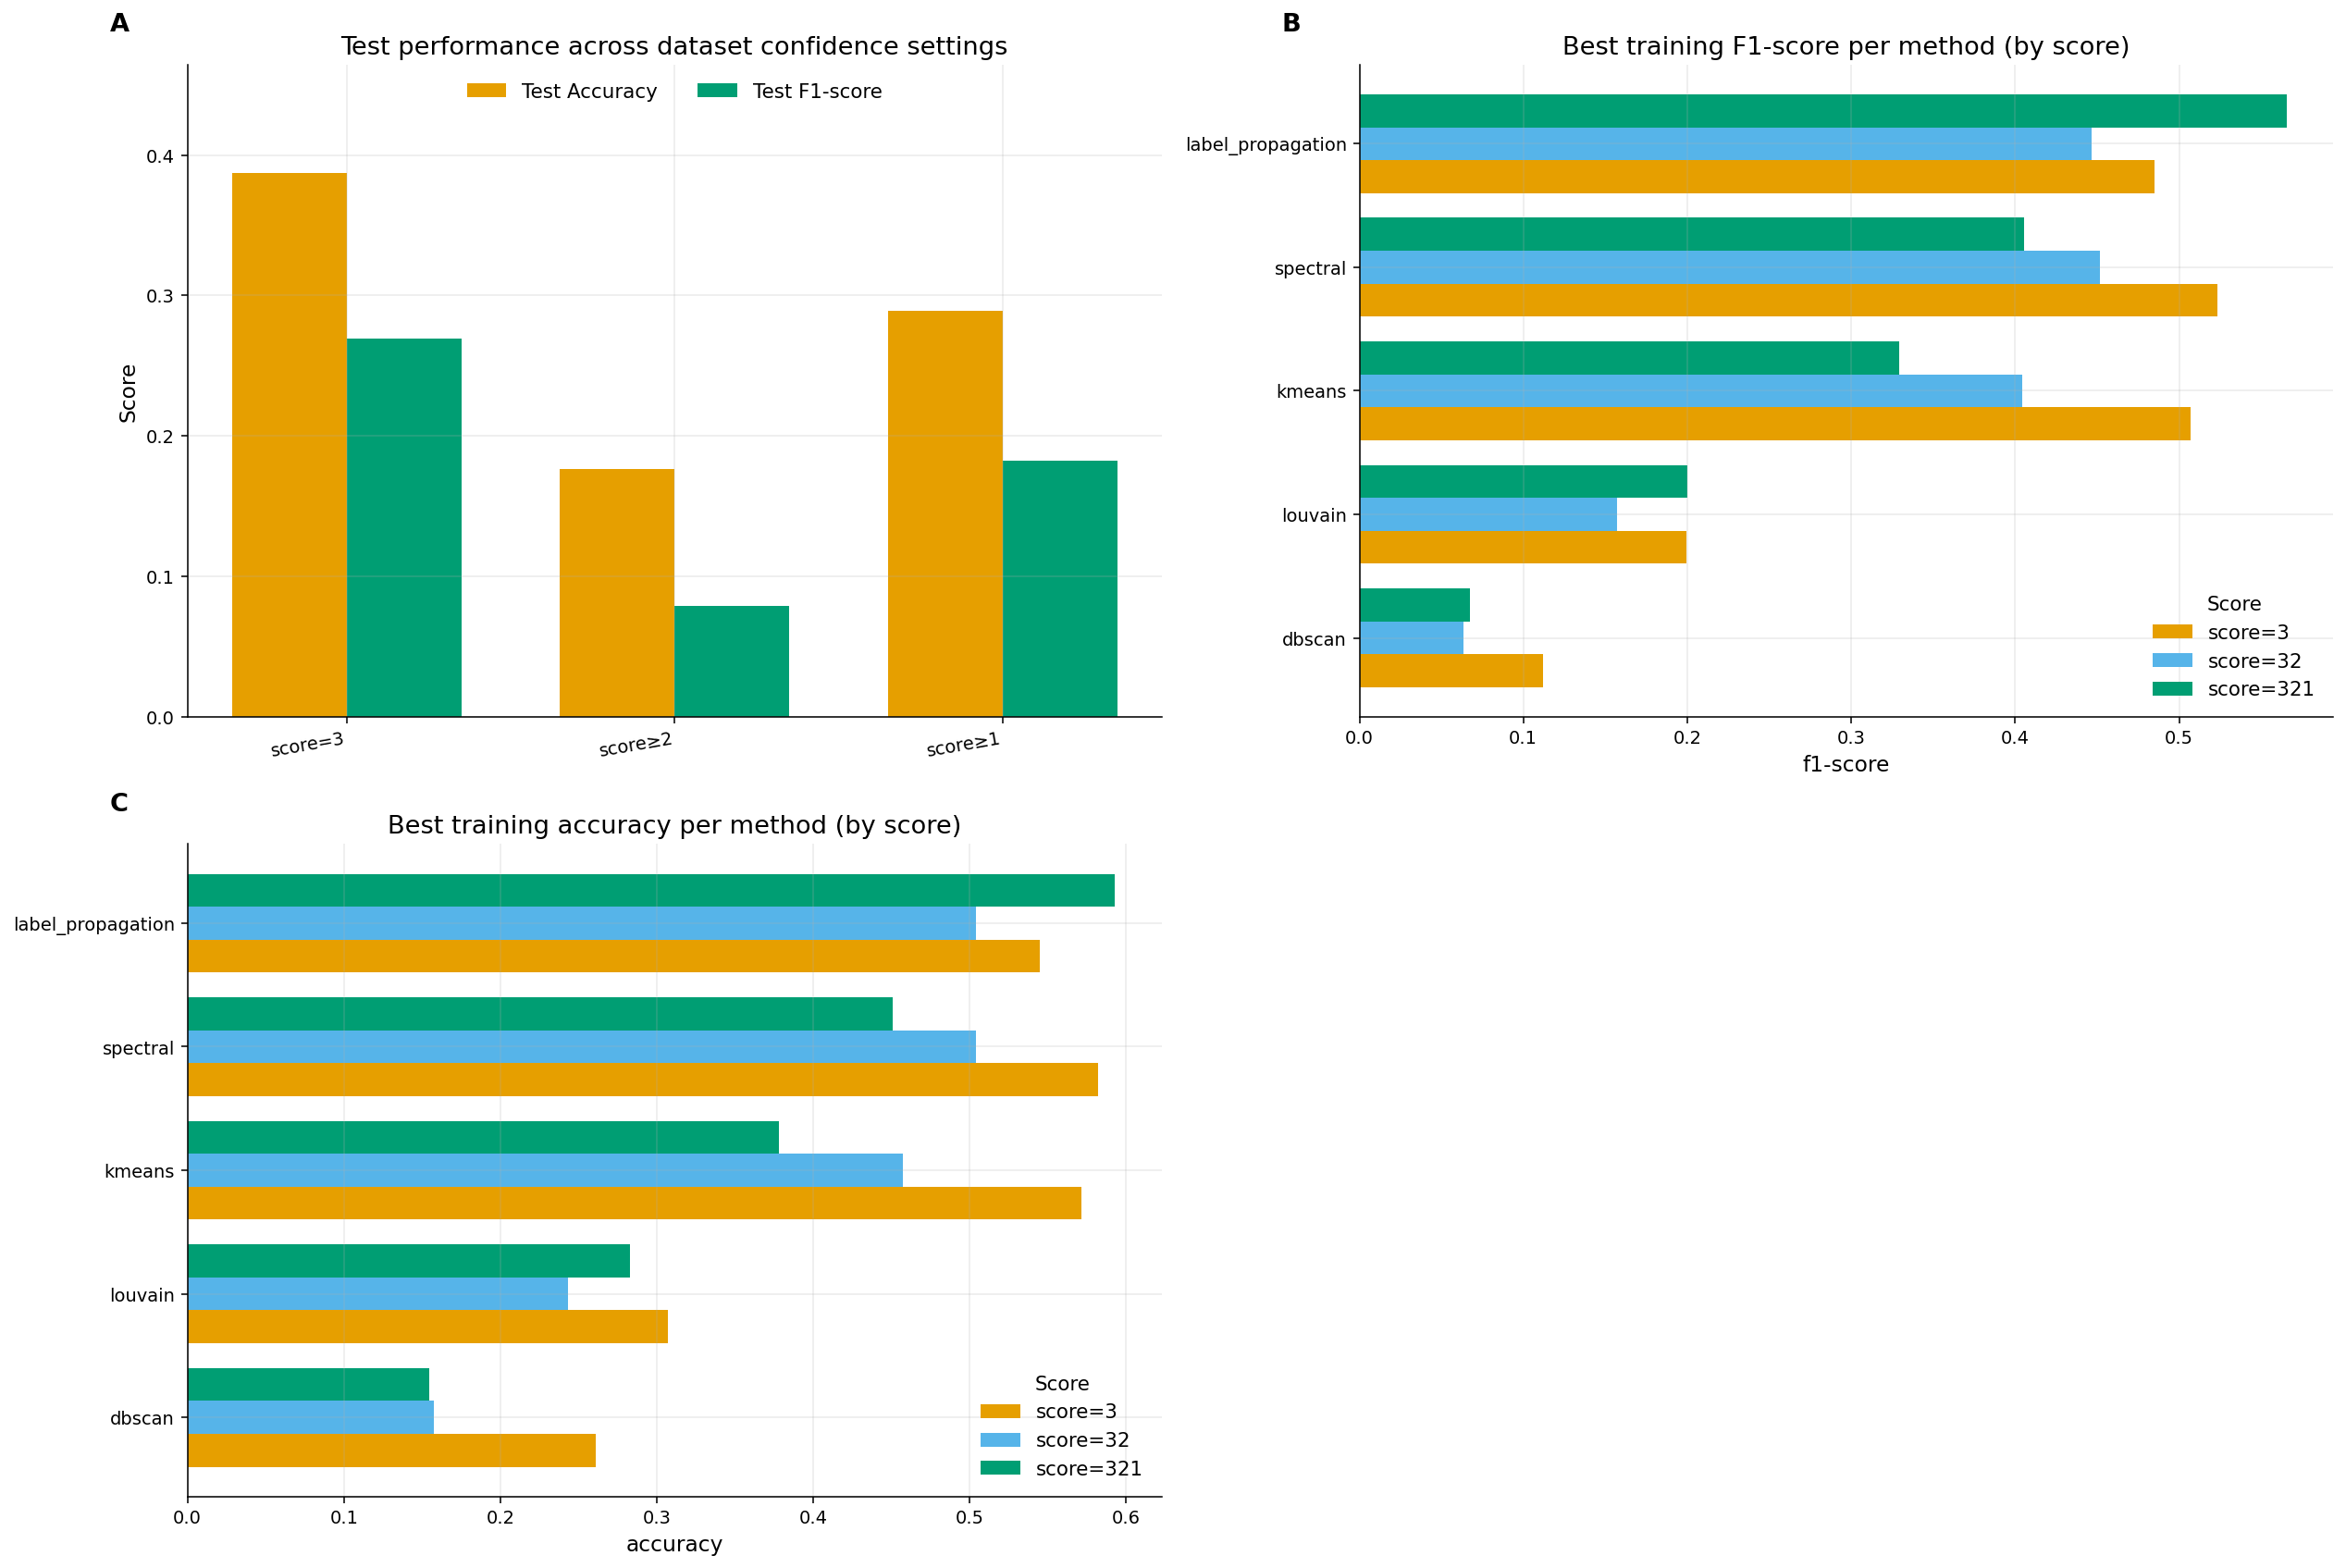

In [58]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

scores = [3, 32, 321]
train_metrics = ["f1_score", "accuracy"]  # removed recall

# ---------- Collect best-per-method train metrics ----------
all_best = []

for score in scores:
    training_csv = f"/home/dsi/chenbis/repos/sol_lab/clustering models prediction/output_by_scores/{score}/training_stats.csv"
    train_df = load_training_stats(training_csv)

    required = {"method"} | set(train_metrics)
    missing = required - set(train_df.columns)
    if missing:
        raise ValueError(f"train_df missing columns for score={score}: {sorted(missing)}")

    for metric in train_metrics:
        best = (
            train_df.dropna(subset=[metric])
            .sort_values(metric, ascending=False)
            .groupby("method", as_index=False)
            .head(1)
            .loc[:, ["method", metric]]
            .assign(score=score, metric=metric)
            .rename(columns={metric: "value"})
        )
        all_best.append(best)

all_best = pd.concat(all_best, ignore_index=True)

# ---------- Color palette (shared) ----------
okabe_ito = [
    "#E69F00",  # orange
    "#56B4E9",  # sky blue
    "#009E73",  # bluish green
    "#F0E442",  # yellow
    "#0072B2",  # blue
    "#D55E00",  # vermillion
    "#CC79A7",  # reddish purple
]

score_colors = okabe_ito[:len(score_vals)]
metric_colors = score_colors

# ---------- Helper function for train metric panels ----------
def plot_train_metric(ax, metric_name, title):
    mat = (
        all_best[all_best["metric"] == metric_name]
        .pivot(index="method", columns="score", values="value")
    )

    # Order methods by average performance
    order = mat.mean(axis=1).sort_values(ascending=True).index
    mat = mat.reindex(order)

    methods = mat.index.tolist()
    y = np.arange(len(methods))
    bar_h = 0.8 / len(score_vals)

    for i, (s, color) in enumerate(zip(score_vals, score_colors)):
        offset = (i - (len(score_vals) - 1) / 2) * bar_h
        ax.barh(y + offset, mat[s].values, height=bar_h, color=color, label=f"score={s}")

    ax.set_yticks(y)
    ax.set_yticklabels(methods)
    ax.set_xlabel(metric_name.replace("_", "-"))
    ax.set_title(title)

# ---------- Build figure ----------
fig, axes = plt.subplots(2, 2, figsize=(18, 12), constrained_layout=True)

# ===== Panel A: Test metrics =====
datasets = summary["dataset"].tolist()
x = np.arange(len(datasets))
w = 0.35  # wider since only two bars now

axes[0, 0].bar(x - w/2, summary["test_accuracy"], w, label="Test Accuracy", color=metric_colors[0])
axes[0, 0].bar(x + w/2, summary["test_f1"],       w, label="Test F1-score", color=metric_colors[2])

axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(datasets, rotation=10, ha="right")
axes[0, 0].set_ylabel("Score")
axes[0, 0].set_title("Test performance across dataset confidence settings")
axes[0, 0].set_ylim(
    0,
    float(summary[["test_accuracy", "test_f1"]].max().max()) * 1.2
)
axes[0, 0].legend(ncol=2, loc="upper center", frameon=False)

# ===== Panel B: Train F1 =====
plot_train_metric(
    axes[0, 1],
    "f1_score",
    "Best training F1-score per method (by score)"
)
axes[0, 1].legend(title="Score", frameon=False)

# ===== Panel C: Train Accuracy =====
plot_train_metric(
    axes[1, 0],
    "accuracy",
    "Best training accuracy per method (by score)"
)
axes[1, 0].legend(title="Score", frameon=False)

# ===== Panel D: unused (hide it) =====
axes[1, 1].axis("off")

# ---------- Panel labels ----------
panel_labels = ["A", "B", "C", ""]  # no label for hidden panel
for ax, label in zip(axes.flat, panel_labels):
    if not label:
        continue
    ax.text(
        -0.08, 1.08, label,
        transform=ax.transAxes,
        fontsize=14,
        fontweight="bold",
        va="top",
        ha="left"
    )

plt.show()

# Optional save
# outpath = Path("/home/dsi/chenbis/repos/sol_lab/clustering models prediction/figures/combined/train_test_4panel.png")
# outpath.parent.mkdir(parents=True, exist_ok=True)
# fig.savefig(outpath, dpi=200)
